# AKNA PureCLIP reproducibility and genomic annotation

## Purpose and analysis outline

This analysis assesses support for each WT-defined candidate binding site in
the three individual WT biological replicates. Signal is summed across each
site on the matching strand, using the individually normalized crosslink tracks.
A replicate-specific cutoff is the larger of its 10th-percentile site signal
and 2. Candidates supported in **at least two of three WT replicates** are retained.
For the manuscript inputs, all three cutoffs evaluate to 2.

The supported sites are then assigned to protein-coding genes and gene-body
regions using filtered GENCODE M25. Sites overlapping exactly one protein-coding
gene and an annotated region are exported with their replicate signals and
PureCLIP scores. The primary workbook is sorted by mean WT PureCLIP score.

**Inputs:** the pooled-WT curated BED from analysis 01, six WT BigWigs (three
replicates × two strands), GENCODE M25 GTF, and WT/pooled-WT PureCLIP position BEDs.
**Outputs:** an annotated BED, a metadata-rich CSV, and an Excel workbook with
one `all_reproducible_binding_sites` sheet. CSV/workbook coordinates are 1-based
inclusive; BED coordinates are 0-based half-open.

Analysis 03 measures KO signal at these same sites and applies the WT/KO filter.
GO enrichment is performed afterward in analysis 04, using the enriched genes.

## Input/output configuration

Edit these paths before running the analysis. Relative paths are resolved from the repository root. Run the cells in order using the R kernel.

Use the annotation GTF and the curated candidate BED specified above. The six
`wt*_bw` inputs must be individual, strand-specific normalized tracks, not pooled
or group-average tracks. `peak_calling_dir` supplies the position BEDs used only
for score annotation. Keep the CSV and workbook outputs together for analysis 03.

In [1]:
params <- list(
  annotation_gtf = "data/reference/gencode.vM25.annotation.gtf",
  curated_sites = "results/analysis/01_pureclip_postprocessing/replicates_noKO_curated_peaks.bed",
  wt1_plus_bw = "results/preprocessing/akna/crosslinked_nucleotides/WT1.plus.bw",
  wt1_minus_bw = "results/preprocessing/akna/crosslinked_nucleotides/WT1.minus.bw",
  wt2_plus_bw = "results/preprocessing/akna/crosslinked_nucleotides/WT2.plus.bw",
  wt2_minus_bw = "results/preprocessing/akna/crosslinked_nucleotides/WT2.minus.bw",
  wt3_plus_bw = "results/preprocessing/akna/crosslinked_nucleotides/WT3.plus.bw",
  wt3_minus_bw = "results/preprocessing/akna/crosslinked_nucleotides/WT3.minus.bw",
  peak_calling_dir = "results/preprocessing/akna/peak_calling",
  utils_r = "workflow/utils/utils.r",
  output_bed = "results/analysis/02_reproducibility/bs_clean_noKO.bed",
  output_csv = "results/analysis/02_reproducibility/bs_clean_noKO.csv",
  output_workbook = "results/analysis/02_reproducibility/reproducible_binding_sites_groups_noKO.xlsx"
)

project_root <- normalizePath(getwd(), mustWork = TRUE)
if (!file.exists(file.path(project_root, "workflow", "Snakefile"))) {
  project_root <- normalizePath(file.path(project_root, ".."), mustWork = TRUE)
}
if (!file.exists(file.path(project_root, "workflow", "Snakefile"))) {
  stop("Open this notebook from the repository root or its analysis directory.")
}
resolve_repo_path <- function(path) {
  if (grepl("^(/|[A-Za-z]:[/\\\\])", path)) path else file.path(project_root, path)
}
paths <- lapply(params, resolve_repo_path)


## Load packages and shared helpers

The shared helpers sum track signal over intervals and flatten list-valued
annotations for tabular export. Output directories are created before analysis.

In [2]:

library(rtracklayer)
library(GenomicRanges)
library(ggplot2)
library(dplyr)
library(reshape2)
library(UpSetR)
library(GenomicFeatures)
library(readr)
library(openxlsx)

source(paths$utils_r)
dir.create(dirname(paths$output_bed), recursive = TRUE, showWarnings = FALSE)
dir.create(dirname(paths$output_csv), recursive = TRUE, showWarnings = FALSE)
dir.create(dirname(paths$output_workbook), recursive = TRUE, showWarnings = FALSE)


## Peak reproducibility across WT replicates

Load each replicate and strand explicitly. The candidate BED is imported as
`GRanges`, restricted to standard chromosomes, and cleared of prior metadata
before new site-level measurements are added.

In [3]:
tracks <- list(
  WT1 = list(
    plus = import(paths$wt1_plus_bw, "BigWig", as = "Rle"),
    minus = import(paths$wt1_minus_bw, "BigWig", as = "Rle")
  ),
  WT2 = list(
    plus = import(paths$wt2_plus_bw, "BigWig", as = "Rle"),
    minus = import(paths$wt2_minus_bw, "BigWig", as = "Rle")
  ),
  WT3 = list(
    plus = import(paths$wt3_plus_bw, "BigWig", as = "Rle"),
    minus = import(paths$wt3_minus_bw, "BigWig", as = "Rle")
  )
)

bs <- import(paths$curated_sites, format = "BED")
bs <- keepStandardChromosomes(bs, pruning.mode = "coarse")
mcols(bs) <- NULL


### Sum crosslink signal and evaluate replicate support

Sum signal over the whole candidate interval separately for each replicate and
strand. The histogram caps displayed values at 40 for readability; the cutoff
and reproducibility calculations use the original, uncapped signal.

The red lines show the replicate-specific cutoffs. The UpSet plot summarizes
sets of sites meeting each replicate's cutoff. The final `filter` flag requires
support in at least two replicates, not significant PureCLIP calls in two samples.

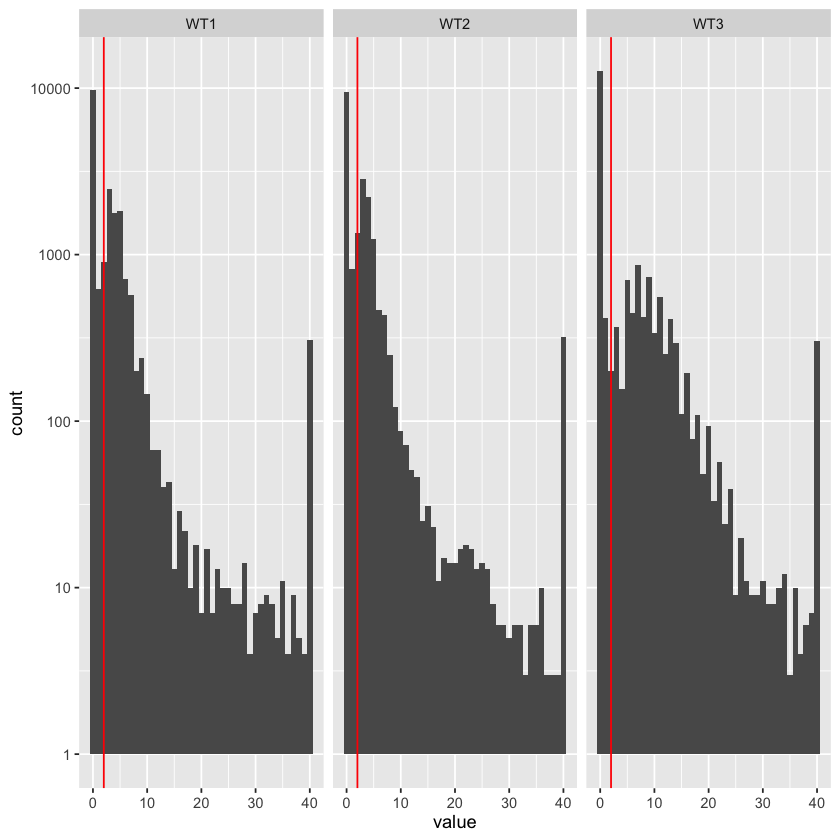

Sites reproducible in at least two WT replicates: 4172 


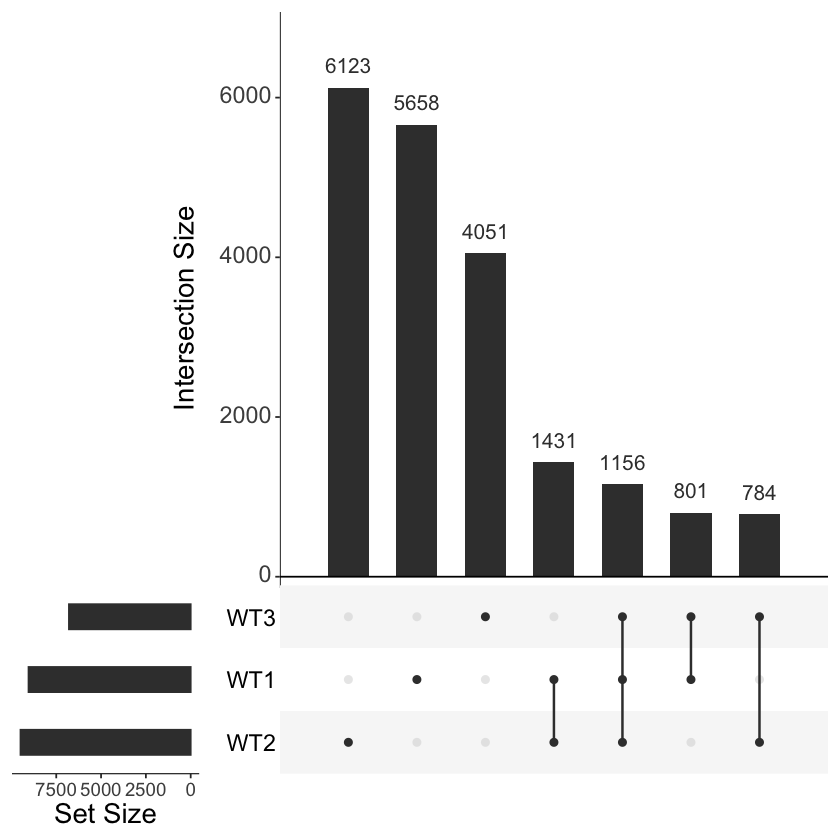

In [4]:
# Sum crosslink signal over each site using its matching strand.
bs.p <- bs[strand(bs) == "+"]
bs.m <- bs[strand(bs) == "-"]

for (sample in names(tracks)) {
  mcols(bs.p)[[sample]] <- sum_track_over_ranges(tracks[[sample]]$plus, bs.p)
  mcols(bs.m)[[sample]] <- sum_track_over_ranges(tracks[[sample]]$minus, bs.m)
}
bs <- c(bs.p, bs.m)

# Cap the plotting copy only; bs retains the original site signals.
df <- as.data.frame(as.matrix(mcols(bs)))
df[df > 40] <- 40
df <- reshape2::melt(df)

# Calculate each replicate’s 10th percentile and enforce a lower boundary of 2.
aa <- data.frame(
  cutoff = c(
    quantile(bs$WT1, probs = seq(0, 1, by = 0.1))[2],
    quantile(bs$WT2, probs = seq(0, 1, by = 0.1))[2],
    quantile(bs$WT3, probs = seq(0, 1, by = 0.1))[2]
  ),
  variable = c("WT1", "WT2", "WT3")
)
aa$cutoff[aa$cutoff < 2] <- 2

ggplot(df, aes(x = value, group = variable)) +
  geom_histogram(binwidth = 1) +
  facet_grid(~variable) +
  geom_vline(data = aa, aes(xintercept = cutoff), color = "red") +
  scale_y_log10()

# Overview of sites passing the support cutoff in each replicate.
names(bs) <- seq_along(bs)
NameList <- list(
  WT1 = names(bs[bs$WT1 >= aa$cutoff[1]]),
  WT2 = names(bs[bs$WT2 >= aa$cutoff[2]]),
  WT3 = names(bs[bs$WT3 >= aa$cutoff[3]])
)
upset(fromList(NameList), order.by = "freq", nsets = 3,
      text.scale = c(2, 2, 2, 1.6, 2, 2))

# Annotate support and apply the two-of-three reproducibility filter.
status <- data.frame(
  r1 = as.integer(bs$WT1 >= aa$cutoff[1]),
  r2 = as.integer(bs$WT2 >= aa$cutoff[2]),
  r3 = as.integer(bs$WT3 >= aa$cutoff[3])
)
bs$filter <- rowSums(status) >= 2
bs.filter <- bs[bs$filter]
names(bs.filter) <- seq_along(bs.filter)
cat("Sites reproducible in at least two WT replicates:", length(bs.filter), "\n")


## Genomic annotation of reproducible sites

Filter GENCODE feature records by annotation level (exclude level 3), then retain
transcript-support levels 1–3 and records with a missing TSL attribute. Internal
`0` represents a missing attribute; it is not a GENCODE support level. Literal
`"NA"` values are assigned an excluded placeholder. Construct a transcript
database from the filtered records and attach gene symbols/types from the GTF.

In [5]:
anno <- import(paths$annotation_gtf, format = "GTF")
# Filter feature-level annotation before constructing the transcript database.
anno <- anno[anno$level != 3]
# Preserve missing-attribute records via internal 0; exclude literal "NA" via 10.
anno$transcript_support_level[is.na(anno$transcript_support_level)] <- 0
anno$transcript_support_level[anno$transcript_support_level == "NA"] <- 10
anno <- anno[anno$transcript_support_level %in% c(0, 1, 2, 3)]
# Build a transcript database from the filtered annotation.
anno.db <- makeTxDbFromGRanges(anno)

gns <- GenomicFeatures::genes(anno.db)
idx <- match(gns$gene_id, anno$gene_id)
elementMetadata(gns) <- cbind(
  elementMetadata(gns),
  elementMetadata(anno)[idx, ]
)
bs <- bs.filter


### Gene perspective: overview of overlapping gene types

Count gene types among genes overlapping reproducible sites. This diagnostic
plot precedes the restriction to uniquely assigned protein-coding targets.

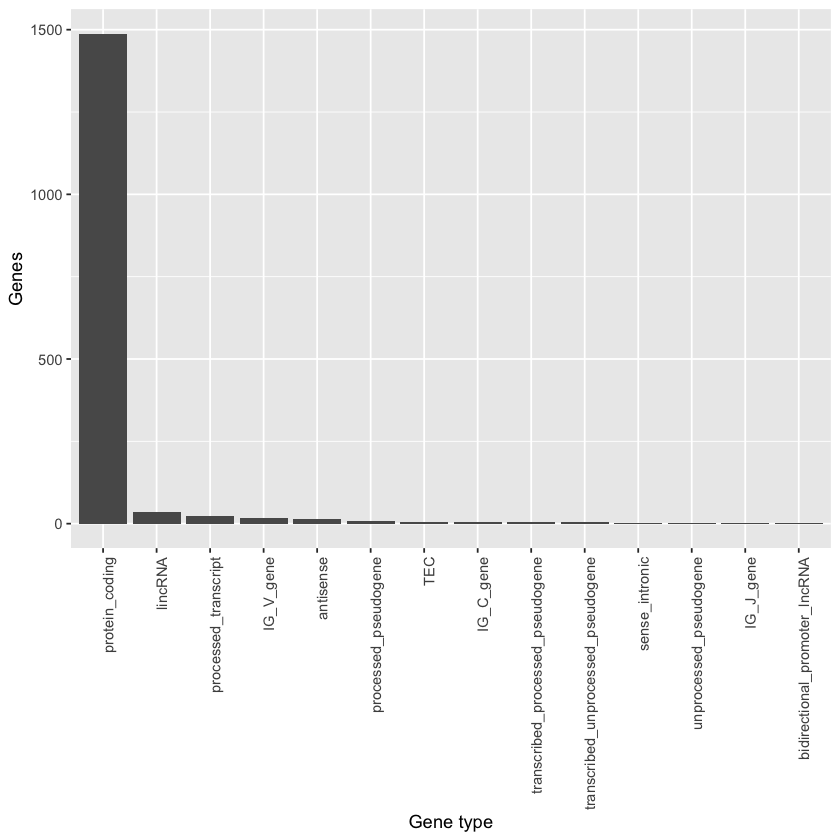

In [6]:
targets <- subsetByOverlaps(gns, bs)
gene_type_counts <- data.frame(gene_type = targets$gene_type) %>%
  table() %>%
  as.data.frame()
ggplot(gene_type_counts, aes(x = reorder(gene_type, -Freq), y = Freq)) +
  geom_bar(stat = "identity") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  xlab("Gene type") + ylab("Genes")


### Binding-site perspective: assign one protein-coding gene

Select protein-coding target genes and retain sites overlapping exactly one such
gene on the matching strand. Attach its identifier, type, and symbol to each site.
The uniqueness test here is among protein-coding targets, not all gene biotypes.

In [7]:
targets <- subsetByOverlaps(gns, bs)
targets.prot <- targets[targets$gene_type == "protein_coding"]
bs.prot <- subsetByOverlaps(bs, targets.prot)
# Keep only sites that overlap one distinct protein-coding target.
bs.clean <- bs.prot[countOverlaps(bs.prot, targets.prot) == 1]

# Attach the uniquely matched gene annotations to each binding site.
overlaps <- findOverlaps(bs.clean, targets.prot)
mcols(bs.clean)$gene_id <- targets.prot$gene_id[subjectHits(overlaps)]
mcols(bs.clean)$gene_type <- targets.prot$gene_type[subjectHits(overlaps)]
mcols(bs.clean)$gene_name <- targets.prot$gene_name[subjectHits(overlaps)]


### Resolve gene-body region overlaps

A binding site may overlap different region annotations across transcript models.
Count overlaps with CDS, intron, 3′ UTR and 5′ UTR features, then assign the region
with the greatest count. Ties follow **CDS → 3′ UTR → 5′ UTR → intron**.
This is a majority-overlap rule. Sites with
no region annotation (`outside`) are removed.

`region_start` and `region_end` retain the boundaries of overlapping features of
the assigned type; multiple values are serialized for export. These are annotation
boundaries, not additional binding sites. `n_replicates_nonzero` counts any nonzero
WT signal and is descriptive.

In [8]:
cds_regions <- cds(anno.db)
intron_regions <- unlist(intronsByTranscript(anno.db))
utr3_regions <- unlist(threeUTRsByTranscript(anno.db))
utr5_regions <- unlist(fiveUTRsByTranscript(anno.db))

# Count overlapping region features at each site across transcript annotations.
count.df <- data.frame(
  cds = countOverlaps(bs.clean, cds_regions),
  intron = countOverlaps(bs.clean, intron_regions),
  utr3 = countOverlaps(bs.clean, utr3_regions),
  utr5 = countOverlaps(bs.clean, utr5_regions)
)
# Set the hierarchy for ties, then apply the majority-overlap assignment.
rule <- c("cds", "utr3", "utr5", "intron")
count.df <- count.df[, rule] %>%
  as.matrix() %>%
  cbind.data.frame(outside = as.integer(rowSums(count.df) == 0))
region_names <- colnames(count.df)
reg <- apply(count.df, 1, function(x) region_names[which.max(x)])
mcols(bs.clean)$region <- reg

# Remove sites outside all four annotated region classes.
keep <- bs.clean$region != "outside"
bs.clean <- bs.clean[keep]
reg <- reg[keep]

# Retain region boundaries from all matching features of the assigned class.
region_ranges <- list(
  cds = cds_regions,
  utr3 = utr3_regions,
  utr5 = utr5_regions,
  intron = intron_regions
)
region_start <- lapply(seq_along(bs.clean), function(i) {
  candidate <- region_ranges[[reg[i]]]
  hits <- subjectHits(findOverlaps(bs.clean[i], candidate))
  if (length(hits) == 0) return(NA_integer_)
  start(candidate[hits])
})
region_end <- lapply(seq_along(bs.clean), function(i) {
  candidate <- region_ranges[[reg[i]]]
  hits <- subjectHits(findOverlaps(bs.clean[i], candidate))
  if (length(hits) == 0) return(NA_integer_)
  end(candidate[hits])
})
mcols(bs.clean)$region_start <- region_start
mcols(bs.clean)$region_end <- region_end

# Descriptive count of replicates with nonzero signal, not the number
# passing the reproducibility cutoff used for site selection above.
mcols(bs.clean)$n_replicates_nonzero <- rowSums(
  cbind(bs.clean$WT1, bs.clean$WT2, bs.clean$WT3) != 0
)


## Extract PureCLIP scores for annotated binding sites

Load significant-position BEDs for WT1, WT2, WT3 and pooled WT and attach scores
from overlapping positions. BED import handles the coordinate conversion.
For multiple positions in a site, the existing assignment retains the last hit
in input order. No hit produces a missing score. The mean WT score excludes
missing values and is used to sort the export, not to select sites or calculate
WT/KO enrichment. Replicate support above is based on normalized crosslink signal.

In [9]:
for (sample in c("WT1", "WT2", "WT3", "replicates")) {
  peak_file <- file.path(
    paths$peak_calling_dir,
    paste0(sample, "_noinputcontroldata_PureCLIP.crosslink_sites_short.bed")
  )
  # BED starts are 0-based; import converts them to 1-based GRanges.
  peaks_gr <- rtracklayer::import(peak_file, format = "BED")
  score_overlaps <- findOverlaps(bs.clean, peaks_gr)
  scores <- rep(NA_real_, length(bs.clean))
  # For multiple hits, retain the last overlapping position's score in
  # input order, as in the original analysis. These descriptive scores
  # do not determine reproducibility or WT/KO enrichment.
  scores[queryHits(score_overlaps)] <- peaks_gr$score[subjectHits(score_overlaps)]
  mcols(bs.clean)[[paste0(sample, "_score")]] <- scores
}

score_cols <- as.matrix(
  mcols(bs.clean)[, c("WT1_score", "WT2_score", "WT3_score")]
)
mcols(bs.clean)$average_score <- rowMeans(score_cols, na.rm = TRUE)
bs.clean <- bs.clean[order(-mcols(bs.clean)$average_score)]


## Export filtered and annotated binding sites

Write the 9-nt intervals as BED and retain the full metadata in CSV and Excel.
List-valued annotation boundaries are flattened into semicolon-separated strings.
The primary workbook contains all reproducible annotated sites, including those
that may later fail the WT/KO signal filter. Use its matching CSV and individual
WT/KO tracks as inputs to analysis 03.

In [10]:
export(bs.clean, paths$output_bed, format = "BED")
bs.clean.df <- flatten_list_columns(as.data.frame(bs.clean))
write.csv(bs.clean.df, paths$output_csv, row.names = FALSE)

cat("Annotated reproducible 9-nt sites:", length(bs.clean), "\n")
cat("Unique annotated target genes:", length(unique(bs.clean$gene_name)), "\n")

write.xlsx(
  list(all_reproducible_binding_sites = bs.clean.df),
  file = paths$output_workbook,
  overwrite = TRUE
)


Annotated reproducible 9-nt sites: 2853 


Unique annotated target genes: 1351 
